# PhoBERT + TF-IDF + SentiWordNet End-to-End

Notebook này fine-tune hybrid model theo hướng end-to-end với `gradual unfreezing` cho PhoBERT.


In [ ]:
import os, sys, json, time, random, copy
from pathlib import Path
from datetime import datetime
from collections import Counter

IN_COLAB = False
try:
    from google.colab import drive  # type: ignore
    IN_COLAB = True
except ImportError:
    drive = None

if IN_COLAB:
    drive.mount('/content/drive')

def find_project_root():
    if IN_COLAB:
        root = Path('/content/drive/MyDrive/Student-Feedback-Sentiment-Analysis')
        if root.exists():
            return root
        raise FileNotFoundError(root)
    cwd = Path.cwd().resolve()
    for candidate in [cwd] + list(cwd.parents):
        if (candidate / 'src').exists() and (candidate / 'data').exists() and (candidate / 'results').exists():
            return candidate
    raise FileNotFoundError('Project root not found')

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
print(f'Project root: {PROJECT_ROOT}')


Mounted at /content/drive
Project root: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis


In [ ]:
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score, precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from IPython.display import display
from tqdm.auto import tqdm
from src.data_utils import load_data, load_sentiwordnet, preprocess_vietnamese, extract_swn_features_extended_batch, SWN_EXTENDED_FEATURE_NAMES

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')


PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
class Config:
    BASE_DIR = str(PROJECT_ROOT)
    DATA_DIR = os.path.join(BASE_DIR, 'data', 'processed')
    SENTIWORDNET_FILE = os.path.join(BASE_DIR, 'data', 'sentiwordnet-dataset', 'VietSentiWordnet_Ver1.3.5.txt')
    MODEL_TYPE = 'PhoBERT_TF-IDF_Sentiwordnet'
    EXPERIMENT_TYPE = 'end_to_end_unfreezing'
    TIMESTAMP = datetime.now().strftime('%Y%m%d_%H%M%S')
    RESULTS_DIR = os.path.join(BASE_DIR, 'results', MODEL_TYPE, EXPERIMENT_TYPE, TIMESTAMP)
    MODELS_DIR = os.path.join(RESULTS_DIR, 'models')
    SUMMARIES_DIR = os.path.join(RESULTS_DIR, 'summaries')
    VISUALIZATIONS_DIR = os.path.join(RESULTS_DIR, 'visualizations')
    ARTIFACTS_DIR = os.path.join(RESULTS_DIR, 'artifacts')

    MODEL_NAME = 'vinai/phobert-base'
    LABEL_MAP = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
    NUM_CLASSES = 3
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    MAX_LENGTH = 256
    BATCH_SIZE = 16
    EPOCHS = 6
    EARLY_STOP_PATIENCE = 2
    WARMUP_RATIO = 0.1
    GRADIENT_CLIP = 1.0
    WEIGHT_DECAY = 0.01
    DROPOUT = 0.3

    PHOBERT_LR_FROZEN = 0.0
    PHOBERT_LR_PARTIAL = 1e-5
    PHOBERT_LR_FULL = 2e-5
    HEAD_LR = 1e-4

    TFIDF_MAX_FEATURES = 5000
    TFIDF_NGRAM_RANGE = (1, 2)
    TFIDF_MIN_DF = 3
    TFIDF_MAX_DF = 0.90
    TFIDF_SUBLINEAR_TF = True

    TFIDF_PROJ_DIM = 256
    SWN_PROJ_DIM = 64
    CLASSIFIER_HIDDEN_DIM = 256

    FREEZE_EPOCHS = 1
    PARTIAL_UNFREEZE_EPOCH = 2
    FULL_UNFREEZE_EPOCH = 4
    PARTIAL_UNFREEZE_LAST_N = 4
    SELECTION_METRIC = 'f1_macro'

config = Config()
for path in [config.RESULTS_DIR, config.MODELS_DIR, config.SUMMARIES_DIR, config.VISUALIZATIONS_DIR, config.ARTIFACTS_DIR]:
    os.makedirs(path, exist_ok=True)
assert os.path.exists(config.SENTIWORDNET_FILE), config.SENTIWORDNET_FILE
print(f'Results dir: {config.RESULTS_DIR}')
print(f'Device: {config.DEVICE}')
print(f'Epochs: {config.EPOCHS}')
print(f'Gradual unfreezing: freeze<{config.PARTIAL_UNFREEZE_EPOCH}, partial@{config.PARTIAL_UNFREEZE_EPOCH}-{config.FULL_UNFREEZE_EPOCH - 1}, full@{config.FULL_UNFREEZE_EPOCH}+')


Results dir: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_TF-IDF_Sentiwordnet/end_to_end_unfreezing/20260317_151602
Device: cuda
Epochs: 6
Gradual unfreezing: freeze<2, partial@2-3, full@4+


In [ ]:
train_texts, train_labels = load_data(config.DATA_DIR, 'train')
val_texts, val_labels = load_data(config.DATA_DIR, 'validation')
test_texts, test_labels = load_data(config.DATA_DIR, 'test')

for split_name, labels in [('Train', train_labels), ('Validation', val_labels), ('Test', test_labels)]:
    counter = Counter(labels)
    print(f'[{split_name}] total={len(labels)}')
    for idx, name in config.LABEL_MAP.items():
        count = counter.get(idx, 0)
        print(f'  {name}: {count} ({count / len(labels) * 100:.2f}%)')


[Train] total=11426
  Negative: 5325 (46.60%)
  Neutral: 458 (4.01%)
  Positive: 5643 (49.39%)
[Validation] total=1583
  Negative: 705 (44.54%)
  Neutral: 73 (4.61%)
  Positive: 805 (50.85%)
[Test] total=3166
  Negative: 1409 (44.50%)
  Neutral: 167 (5.27%)
  Positive: 1590 (50.22%)


In [ ]:
train_texts_processed = [preprocess_vietnamese(text) for text in train_texts]
val_texts_processed = [preprocess_vietnamese(text) for text in val_texts]
test_texts_processed = [preprocess_vietnamese(text) for text in test_texts]

tfidf_vectorizer = TfidfVectorizer(max_features=config.TFIDF_MAX_FEATURES, ngram_range=config.TFIDF_NGRAM_RANGE, min_df=config.TFIDF_MIN_DF, max_df=config.TFIDF_MAX_DF, sublinear_tf=config.TFIDF_SUBLINEAR_TF)
train_tfidf = tfidf_vectorizer.fit_transform(train_texts_processed).astype(np.float32)
val_tfidf = tfidf_vectorizer.transform(val_texts_processed).astype(np.float32)
test_tfidf = tfidf_vectorizer.transform(test_texts_processed).astype(np.float32)
joblib.dump(tfidf_vectorizer, os.path.join(config.ARTIFACTS_DIR, 'tfidf_vectorizer.pkl'))
print(f'TFIDF shapes: {train_tfidf.shape}, {val_tfidf.shape}, {test_tfidf.shape}')


TFIDF shapes: (11426, 5000), (1583, 5000), (3166, 5000)


In [ ]:
word_to_scores = load_sentiwordnet(config.SENTIWORDNET_FILE)
train_swn = extract_swn_features_extended_batch(train_texts, word_to_scores).astype(np.float32)
val_swn = extract_swn_features_extended_batch(val_texts, word_to_scores).astype(np.float32)
test_swn = extract_swn_features_extended_batch(test_texts, word_to_scores).astype(np.float32)

swn_scaler = StandardScaler()
train_swn_scaled = swn_scaler.fit_transform(train_swn).astype(np.float32)
val_swn_scaled = swn_scaler.transform(val_swn).astype(np.float32)
test_swn_scaled = swn_scaler.transform(test_swn).astype(np.float32)
joblib.dump(swn_scaler, os.path.join(config.ARTIFACTS_DIR, 'swn_scaler.pkl'))
print(f'SWN entries: {len(word_to_scores):,}')
print(f'SWN shape: {train_swn_scaled.shape}')


SWN entries: 1,227
SWN shape: (11426, 35)


In [ ]:
class HybridDataset(Dataset):
    def __init__(self, texts, tfidf_features, swn_features, labels, tokenizer, max_length):
        self.texts = texts
        self.tfidf_features = tfidf_features
        self.swn_features = swn_features
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(str(self.texts[idx]), add_special_tokens=True, max_length=self.max_length, padding='max_length', truncation=True, return_tensors='pt')
        tfidf = self.tfidf_features[idx]
        if hasattr(tfidf, 'toarray'):
            tfidf = tfidf.toarray().ravel()
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'tfidf': torch.tensor(tfidf, dtype=torch.float),
            'swn': torch.tensor(self.swn_features[idx], dtype=torch.float),
            'label': torch.tensor(self.labels[idx], dtype=torch.long),
        }

class PhoBERTTFIDFSentiWordNetHybrid(nn.Module):
    def __init__(self, model_name, tfidf_dim, swn_dim, num_classes, dropout=0.3):
        super().__init__()
        self.phobert = AutoModel.from_pretrained(model_name)
        phobert_dim = self.phobert.config.hidden_size
        self.tfidf_proj = nn.Sequential(nn.Linear(tfidf_dim, config.TFIDF_PROJ_DIM), nn.ReLU(), nn.Dropout(dropout))
        self.swn_proj = nn.Sequential(nn.Linear(swn_dim, config.SWN_PROJ_DIM), nn.ReLU(), nn.Dropout(dropout))
        combined_dim = phobert_dim + config.TFIDF_PROJ_DIM + config.SWN_PROJ_DIM
        self.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(combined_dim, config.CLASSIFIER_HIDDEN_DIM), nn.ReLU(), nn.Dropout(dropout), nn.Linear(config.CLASSIFIER_HIDDEN_DIM, num_classes))

    def forward(self, input_ids, attention_mask, tfidf_features, swn_features):
        outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        phobert_emb = outputs.last_hidden_state[:, 0, :]
        tfidf_emb = self.tfidf_proj(tfidf_features)
        swn_emb = self.swn_proj(swn_features)
        combined = torch.cat([phobert_emb, tfidf_emb, swn_emb], dim=1)
        return self.classifier(combined)

def count_trainable_params(model):
    return sum(param.numel() for param in model.parameters() if param.requires_grad)

tokenizer = AutoTokenizer.from_pretrained(config.MODEL_NAME)
model = PhoBERTTFIDFSentiWordNetHybrid(config.MODEL_NAME, config.TFIDF_MAX_FEATURES, train_swn_scaled.shape[1], config.NUM_CLASSES, config.DROPOUT).to(config.DEVICE)
print(f'Total params: {sum(param.numel() for param in model.parameters()):,}')
print(f'Initial trainable params: {count_trainable_params(model):,}')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.decoder.bias            | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total params: 136,560,387
Initial trainable params: 136,560,387


In [ ]:
train_dataset = HybridDataset(train_texts, train_tfidf, train_swn_scaled, train_labels, tokenizer, config.MAX_LENGTH)
val_dataset = HybridDataset(val_texts, val_tfidf, val_swn_scaled, val_labels, tokenizer, config.MAX_LENGTH)
test_dataset = HybridDataset(test_texts, test_tfidf, test_swn_scaled, test_labels, tokenizer, config.MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False)

print(f'Batches: train={len(train_loader)}, val={len(val_loader)}, test={len(test_loader)}')


Batches: train=715, val=99, test=198


In [ ]:
class_weights = compute_class_weight(class_weight='balanced', classes=np.array([0, 1, 2]), y=np.array(train_labels))
class_weights = torch.tensor(class_weights, dtype=torch.float).to(config.DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights)

def get_training_stage(epoch_number):
    if epoch_number < config.PARTIAL_UNFREEZE_EPOCH:
        return 'frozen'
    if epoch_number < config.FULL_UNFREEZE_EPOCH:
        return 'partial'
    return 'full'

def set_phobert_trainable_layers(model, stage):
    for param in model.phobert.parameters():
        param.requires_grad = False

    if stage == 'partial':
        encoder_layers = model.phobert.encoder.layer
        for layer in encoder_layers[-config.PARTIAL_UNFREEZE_LAST_N:]:
            for param in layer.parameters():
                param.requires_grad = True
    elif stage == 'full':
        for param in model.phobert.parameters():
            param.requires_grad = True

    for module in [model.tfidf_proj, model.swn_proj, model.classifier]:
        for param in module.parameters():
            param.requires_grad = True

def build_optimizer_and_scheduler(model, stage, epoch_number):
    phobert_lr = {'frozen': config.PHOBERT_LR_FROZEN, 'partial': config.PHOBERT_LR_PARTIAL, 'full': config.PHOBERT_LR_FULL}[stage]
    optimizer_groups = []
    phobert_params = [param for param in model.phobert.parameters() if param.requires_grad]
    head_params = [param for module in [model.tfidf_proj, model.swn_proj, model.classifier] for param in module.parameters() if param.requires_grad]
    if phobert_params:
        optimizer_groups.append({'params': phobert_params, 'lr': phobert_lr})
    optimizer_groups.append({'params': head_params, 'lr': config.HEAD_LR})
    optimizer = torch.optim.AdamW(optimizer_groups, weight_decay=config.WEIGHT_DECAY)
    remaining_epochs = config.EPOCHS - epoch_number + 1
    total_steps = max(1, remaining_epochs * len(train_loader))
    warmup_steps = int(total_steps * config.WARMUP_RATIO)
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)
    return optimizer, scheduler, phobert_lr, total_steps, warmup_steps

set_phobert_trainable_layers(model, 'frozen')
print(f'Class weights: {class_weights.tolist()}')
print(f'Trainable params after freeze setup: {count_trainable_params(model):,}')


Class weights: [0.7152425646781921, 8.315866470336914, 0.6749364733695984]
Trainable params after freeze setup: 1,562,115


In [ ]:
def train_epoch(model, dataloader, criterion, optimizer, scheduler, device):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []
    for batch in tqdm(dataloader, desc='Training', leave=False):
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        tfidf = batch['tfidf'].to(device)
        swn = batch['swn'].to(device)
        labels = batch['label'].to(device)
        logits = model(input_ids, attention_mask, tfidf, swn)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), config.GRADIENT_CLIP)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, accuracy, f1_macro

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Evaluating', leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            tfidf = batch['tfidf'].to(device)
            swn = batch['swn'].to(device)
            labels = batch['label'].to(device)
            logits = model(input_ids, attention_mask, tfidf, swn)
            loss = criterion(logits, labels)
            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())
    avg_loss = total_loss / len(dataloader)
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    f1_weighted = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    accuracy = accuracy_score(all_labels, all_preds)
    precision_pc, recall_pc, f1_pc, support_pc = precision_recall_fscore_support(all_labels, all_preds, labels=[0, 1, 2], zero_division=0)
    return {
        'loss': avg_loss,
        'accuracy': accuracy,
        'precision_macro': precision,
        'recall_macro': recall,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'precision_per_class': precision_pc.tolist(),
        'recall_per_class': recall_pc.tolist(),
        'f1_per_class': f1_pc.tolist(),
        'support_per_class': support_pc.tolist(),
        'confusion_matrix': confusion_matrix(all_labels, all_preds, labels=[0, 1, 2]).tolist(),
        'y_pred': list(map(int, all_preds)),
        'y_true': list(map(int, all_labels)),
    }


In [12]:
history = {'epoch': [], 'stage': [], 'train_loss': [], 'train_acc': [], 'train_f1_macro': [], 'val_loss': [], 'val_acc': [], 'val_f1_macro': [], 'phobert_lr': [], 'trainable_params': []}
best_val_f1 = -1.0
best_epoch = 0
best_stage = None
best_model_state = None
patience_counter = 0
current_stage = None
optimizer = None
scheduler = None

print('=' * 70)
print('START TRAINING WITH GRADUAL UNFREEZING')
print('=' * 70)

for epoch in range(1, config.EPOCHS + 1):
    stage = get_training_stage(epoch)
    if stage != current_stage:
        current_stage = stage
        set_phobert_trainable_layers(model, stage)
        optimizer, scheduler, phobert_lr, total_steps, warmup_steps = build_optimizer_and_scheduler(model, stage, epoch)
        print(f'\n[Stage Switch] epoch={epoch} stage={stage} phobert_lr={phobert_lr} trainable_params={count_trainable_params(model):,}')
    print(f'\nEpoch {epoch}/{config.EPOCHS}')
    train_loss, train_acc, train_f1 = train_epoch(model, train_loader, criterion, optimizer, scheduler, config.DEVICE)
    val_metrics = evaluate(model, val_loader, criterion, config.DEVICE)
    history['epoch'].append(epoch)
    history['stage'].append(stage)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_f1_macro'].append(train_f1)
    history['val_loss'].append(val_metrics['loss'])
    history['val_acc'].append(val_metrics['accuracy'])
    history['val_f1_macro'].append(val_metrics['f1_macro'])
    history['phobert_lr'].append(phobert_lr)
    history['trainable_params'].append(count_trainable_params(model))
    print(f'Train  - loss={train_loss:.4f} acc={train_acc:.4f} f1_macro={train_f1:.4f}')
    print(f"Val    - loss={val_metrics['loss']:.4f} acc={val_metrics['accuracy']:.4f} f1_macro={val_metrics['f1_macro']:.4f} f1_neutral={val_metrics['f1_per_class'][1]:.4f}")
    if val_metrics['f1_macro'] > best_val_f1:
        best_val_f1 = val_metrics['f1_macro']
        best_epoch = epoch
        best_stage = stage
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
        torch.save(best_model_state, os.path.join(config.MODELS_DIR, 'best_model.pt'))
        print(f'  -> new best model saved (val macro F1={best_val_f1:.4f})')
    else:
        patience_counter += 1
        print(f'  -> no improvement, patience={patience_counter}/{config.EARLY_STOP_PATIENCE}')
        if patience_counter >= config.EARLY_STOP_PATIENCE:
            print(f'  -> early stopping at epoch {epoch}')
            break

assert best_model_state is not None
model.load_state_dict(best_model_state)
history_df = pd.DataFrame(history)
history_df.to_csv(os.path.join(config.SUMMARIES_DIR, 'training_history.csv'), index=False)
print(f'Best epoch: {best_epoch}, best stage: {best_stage}, best val macro F1: {best_val_f1:.4f}')


START TRAINING WITH GRADUAL UNFREEZING

[Stage Switch] epoch=1 stage=frozen phobert_lr=0.0 trainable_params=1,562,115

Epoch 1/6


Training:   0%|          | 0/715 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/99 [00:00<?, ?it/s]

Train  - loss=0.6646 acc=0.8668 f1_macro=0.6463
Val    - loss=0.7056 acc=0.8939 f1_macro=0.6559 f1_neutral=0.1379
  -> new best model saved (val macro F1=0.6559)

[Stage Switch] epoch=2 stage=partial phobert_lr=1e-05 trainable_params=29,913,603

Epoch 2/6


Training:   0%|          | 0/715 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/99 [00:00<?, ?it/s]

Train  - loss=0.3277 acc=0.9479 f1_macro=0.8566
Val    - loss=0.5487 acc=0.9419 f1_macro=0.8542 f1_neutral=0.6525
  -> new best model saved (val macro F1=0.8542)

Epoch 6/6


Training:   0%|          | 0/715 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/99 [00:00<?, ?it/s]

Train  - loss=0.2138 acc=0.9676 f1_macro=0.9155
Val    - loss=0.6213 acc=0.9450 f1_macro=0.8607 f1_neutral=0.6667
  -> new best model saved (val macro F1=0.8607)
Best epoch: 6, best stage: full, best val macro F1: 0.8607


In [13]:
val_results = evaluate(model, val_loader, criterion, config.DEVICE)
test_results = evaluate(model, test_loader, criterion, config.DEVICE)

print('Validation classification report:')
print(classification_report(val_results['y_true'], val_results['y_pred'], target_names=list(config.LABEL_MAP.values()), zero_division=0))
print('\nTest classification report:')
print(classification_report(test_results['y_true'], test_results['y_pred'], target_names=list(config.LABEL_MAP.values()), zero_division=0))


Evaluating:   0%|          | 0/99 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/198 [00:00<?, ?it/s]

Validation classification report:
              precision    recall  f1-score   support

    Negative       0.94      0.96      0.95       705
     Neutral       0.69      0.64      0.67        73
    Positive       0.97      0.96      0.96       805

    accuracy                           0.95      1583
   macro avg       0.87      0.85      0.86      1583
weighted avg       0.94      0.95      0.94      1583


Test classification report:
              precision    recall  f1-score   support

    Negative       0.94      0.95      0.94      1409
     Neutral       0.61      0.52      0.56       167
    Positive       0.95      0.95      0.95      1590

    accuracy                           0.93      3166
   macro avg       0.83      0.81      0.82      3166
weighted avg       0.92      0.93      0.93      3166



In [14]:
summary_df = pd.DataFrame([
    {'Split': 'Validation', 'Best_Epoch': best_epoch, 'Best_Stage': best_stage, 'Accuracy': val_results['accuracy'], 'F1_Macro': val_results['f1_macro'], 'F1_Weighted': val_results['f1_weighted'], 'F1_Negative': val_results['f1_per_class'][0], 'F1_Neutral': val_results['f1_per_class'][1], 'F1_Positive': val_results['f1_per_class'][2]},
    {'Split': 'Test', 'Best_Epoch': best_epoch, 'Best_Stage': best_stage, 'Accuracy': test_results['accuracy'], 'F1_Macro': test_results['f1_macro'], 'F1_Weighted': test_results['f1_weighted'], 'F1_Negative': test_results['f1_per_class'][0], 'F1_Neutral': test_results['f1_per_class'][1], 'F1_Positive': test_results['f1_per_class'][2]},
])
display(summary_df)
summary_df.to_csv(os.path.join(config.SUMMARIES_DIR, 'summary.csv'), index=False)

experiment_summary = {
    'model_type': config.MODEL_TYPE,
    'experiment_type': config.EXPERIMENT_TYPE,
    'timestamp': config.TIMESTAMP,
    'epochs_configured': config.EPOCHS,
    'best_epoch': best_epoch,
    'best_stage': best_stage,
    'selection_metric': config.SELECTION_METRIC,
    'best_val_f1_macro': best_val_f1,
    'unfreezing_schedule': {
        'freeze_epochs': list(range(1, config.PARTIAL_UNFREEZE_EPOCH)),
        'partial_unfreeze_start_epoch': config.PARTIAL_UNFREEZE_EPOCH,
        'partial_unfreeze_last_n_layers': config.PARTIAL_UNFREEZE_LAST_N,
        'full_unfreeze_start_epoch': config.FULL_UNFREEZE_EPOCH
    },
    'validation': val_results,
    'test': test_results,
}
with open(os.path.join(config.SUMMARIES_DIR, 'experiment_summary.json'), 'w', encoding='utf-8') as f:
    json.dump(experiment_summary, f, ensure_ascii=False, indent=2)

with open(os.path.join(config.SUMMARIES_DIR, 'training_results.txt'), 'w', encoding='utf-8') as f:
    f.write('=' * 60 + '\n')
    f.write('TRAINING RESULTS - PhoBERT + TF-IDF + SentiWordNet End-to-End\n')
    f.write('=' * 60 + '\n')
    f.write(f'Date: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}\n')
    f.write(f'Results Dir: {config.RESULTS_DIR}\n')
    f.write(f'Best Epoch: {best_epoch}\n')
    f.write(f'Best Stage: {best_stage}\n')
    f.write(f'Best Val Macro F1: {best_val_f1:.4f}\n')
    f.write(f"Test Accuracy: {test_results['accuracy']:.4f}\n")
    f.write(f"Test F1 Macro: {test_results['f1_macro']:.4f}\n")
    f.write(f"Test F1 Weighted: {test_results['f1_weighted']:.4f}\n")
    f.write(f"Test F1 Neutral: {test_results['f1_per_class'][1]:.4f}\n")
print(f'Saved outputs to: {config.RESULTS_DIR}')


,Split,Best_Epoch,Best_Stage,Accuracy,F1_Macro,F1_Weighted,F1_Negative,F1_Neutral,F1_Positive
0,Validation,6,full,0.945041,0.860710,0.944613,0.952916,0.666667,0.962547
1,Test,6,full,0.927353,0.818315,0.925851,0.943741,0.563107,0.948097


Saved outputs to: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_TF-IDF_Sentiwordnet/end_to_end_unfreezing/20260317_151602


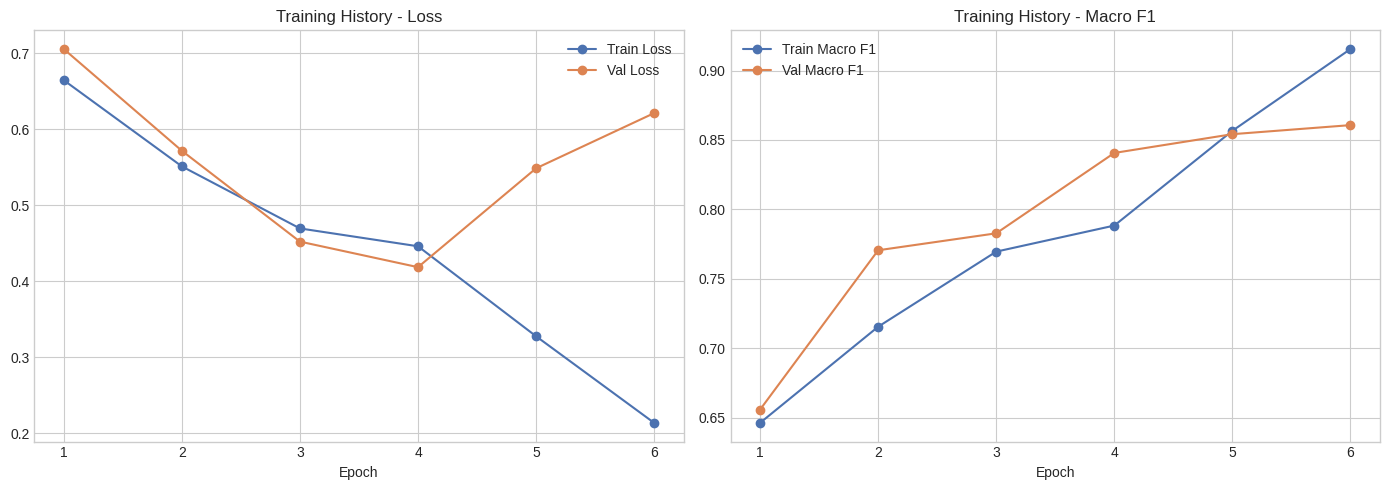

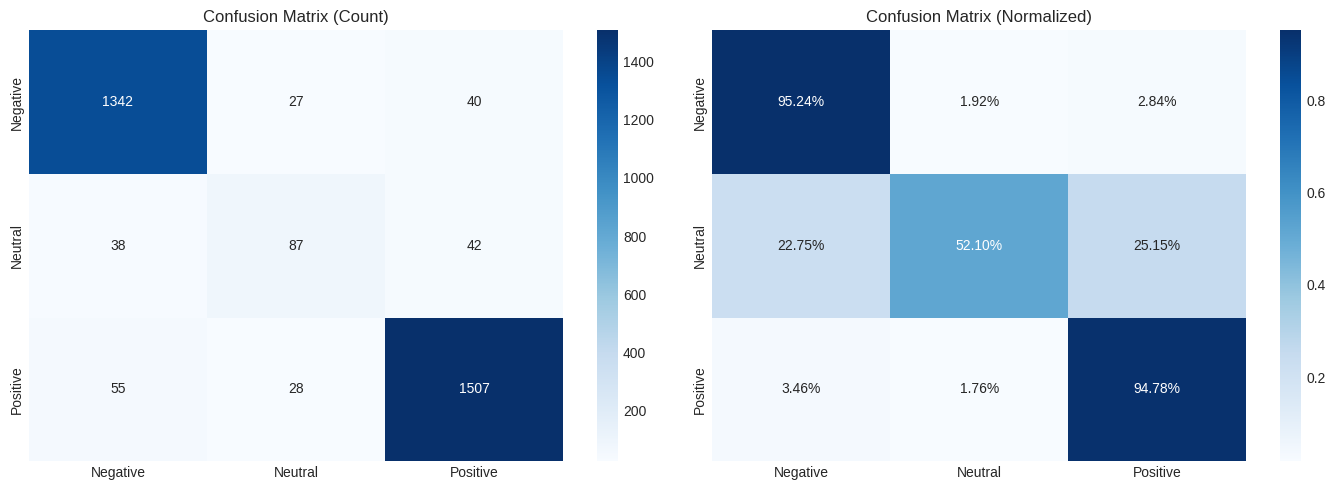

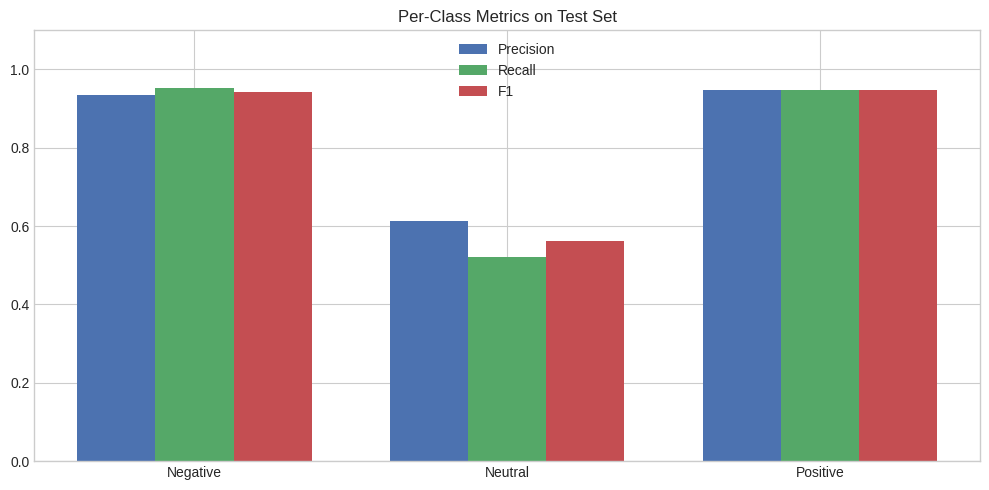

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_df['epoch'], history_df['train_loss'], marker='o', label='Train Loss')
axes[0].plot(history_df['epoch'], history_df['val_loss'], marker='o', label='Val Loss')
axes[0].set_title('Training History - Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[1].plot(history_df['epoch'], history_df['train_f1_macro'], marker='o', label='Train Macro F1')
axes[1].plot(history_df['epoch'], history_df['val_f1_macro'], marker='o', label='Val Macro F1')
axes[1].set_title('Training History - Macro F1')
axes[1].set_xlabel('Epoch')
axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'training_history.png'), dpi=150, bbox_inches='tight')
plt.show()

cm = np.array(test_results['confusion_matrix'])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=list(config.LABEL_MAP.values()), yticklabels=list(config.LABEL_MAP.values()), ax=axes[0])
axes[0].set_title('Confusion Matrix (Count)')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', xticklabels=list(config.LABEL_MAP.values()), yticklabels=list(config.LABEL_MAP.values()), ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)')
plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(config.LABEL_MAP))
width = 0.25
ax.bar(x - width, test_results['precision_per_class'], width, label='Precision', color='#4C72B0')
ax.bar(x, test_results['recall_per_class'], width, label='Recall', color='#55A868')
ax.bar(x + width, test_results['f1_per_class'], width, label='F1', color='#C44E52')
ax.set_xticks(x)
ax.set_xticklabels(list(config.LABEL_MAP.values()))
ax.set_ylim(0, 1.1)
ax.set_title('Per-Class Metrics on Test Set')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'per_class_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()
